# Análisis de permanencia y riesgo de no continuidad estudiantil — CEFIT

**Trabajo aplicado de Ciencia de Datos · Universidad Libre Seccional Cali**

**Propuesta:** *Producto de datos para la identificación temprana del riesgo de deserción estudiantil en CEFIT*

Este cuaderno desarrolla el análisis exploratorio del dataset institucional del **Centro de Formación Integral para el Trabajo (CEFIT)**. Sigue la estructura solicitada por el profesor: para cada pregunta se presenta el **código**, el **resultado** (tabla o gráfico), la **respuesta** y la **conclusión / hipótesis**.

El alcance de este cuaderno es la **analítica descriptiva** (caracterización, patrones y calidad de datos), que es la base del modelo predictivo y del tablero propuestos en el documento.

---

## Paso 1 · Definición del dataset

| | |
|---|---|
| **Nombre** | Estudiantes Matriculados y Graduados CEFIT |
| **Origen** | Registros institucionales de estudiantes de CEFIT (archivo suministrado para el proyecto) |
| **Registros** | 13.461 |
| **Variables** | 21 |
| **Tipo** | Datos estructurados (categóricos, fechas y numéricos) |

**Grupos de variables**
- **Sociodemográficas:** Género, Estado civil, Edad, Estrato, Grupo Sisbén, Multiculturalidad.
- **Ubicación:** Municipio de Nacimiento, País, Municipio Dirección, Barrio Dirección, Zona.
- **Académicas:** Nivel de formación, Jornada, Programa, Período, Nivel.
- **Condición del estudiante:** Ocupación, Medio de Transporte, EPS.
- **Resultado académico (variable objetivo candidata):** Estado.


## Paso 2 · Preguntas de análisis

Las preguntas se alinean con los objetivos de la propuesta y con los cinco tipos de pregunta de la ciencia de datos:

1. **¿Cómo se distribuyen los estudiantes según su Estado, y qué proporción está en continuidad frente a no continuidad?** *(estimación)*
2. **¿Cuál es el perfil sociodemográfico de los estudiantes** (género, edad, estrato, zona)**?** *(descubrimiento)*
3. **¿Qué jornadas concentran la mayor tasa de no continuidad?** *(clasificación / estimación)*
4. **¿Qué programas presentan mayor y menor riesgo de no continuidad?** *(clasificación)*
5. **¿Existe relación entre la edad y el género del estudiante con su continuidad?** *(descubrimiento)*
6. **¿Cómo ha evolucionado la matrícula a lo largo de los períodos?** *(estimación / planeación)*
7. **¿Qué problemas de calidad de datos y anomalías presenta el dataset?** *(detección de anomalías)*


## Paso 3 · Carga de los datos en Pandas

> **Nota:** coloca este cuaderno en la misma carpeta que el archivo CSV. Si tu archivo tiene otro nombre, cámbialo en la variable `RUTA`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', None)

RUTA = 'dataset_cefit.csv'  # ajusta el nombre si es necesario
df = pd.read_csv(RUTA)

print('Dimensiones (filas, columnas):', df.shape)
df.head()

Dimensiones (filas, columnas): (13461, 21)


,Género,Municipio de Nacimiento,País,Municipio Dirección,Barrio Dirección,Estrato,Estado civil,EPS,Grupo Sisben,Zona,Nivel de formación,Ocupación,Medio de Transporte,Multiculturalidad,Estado,Fecha de Matrícula,Jornada,Programa,Período,Nivel,Edad
0,Femenino,Medellín,Colombia,Envigado,Las Flores,3.0,Soltero(a),EPS Sura,Sin respuesta,Urbana,Básica secundaria,Estudiante básica,A Pie,No aplica,Graduado,2018-02-05T10:00:00Z,MEDIA TÉCNICA,MEDIA TÉCNICA TECNICO LABORAL AUXILIAR ADMINIS...,2018-2,SEMESTRE 2,20.0
1,Femenino,Envigado,Colombia,Envigado,San José,2.0,Soltero(a),EPS Sura,Sin respuesta,Urbana,Media,Estudiante superior,Público Metro,No aplica,Graduado,2016-01-19T10:00:00Z,NOCHE,10T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO...,2016-2,SEMESTRE 2,29.0
2,Masculino,Bogotá,Colombia,La Mesa,Sin respuesta,3.0,Soltero(a),No Aplica,Sin respuesta,Rural,Media,Estudiante superior,Transmilenio,No aplica,Cancelado,2021-02-08T10:00:00Z,NOCHE,09T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,2021-2,SEMESTRE 1,19.0
3,Masculino,Envigado,Colombia,Envigado,San José,2.0,Soltero(a),SISBEN,B3,Urbana,Media,Estudiante superior,Público Bus o Buseta,No aplica,Graduado,2020-01-17T10:00:00Z,DIURNA,01T-TÉCNICO LABORAL AUXILIAR DE TALENTO HUMANO,2021-1,SEMESTRE 2,21.0
4,Masculino,Medellín,Colombia,Envigado,El Salado,2.0,Soltero(a),Nueva Promotora de Salud - Nueva EPS,N0,Urbana,Media,Estudiante superior,Moto,No aplica,Inactivo,2020-01-27T10:00:00Z,NOCHE,27T-TÉCNICO LABORAL EN MERCADEO Y VENTAS (Estu...,2020-1,SEMESTRE 1,20.0


In [2]:
# Vista general de tipos y memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13461 entries, 0 to 13460
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Género                   13461 non-null  str    
 1   Municipio de Nacimiento  13461 non-null  str    
 2   País                     13461 non-null  str    
 3   Municipio Dirección      13407 non-null  str    
 4   Barrio Dirección         13461 non-null  str    
 5   Estrato                  12193 non-null  float64
 6   Estado civil             13461 non-null  str    
 7   EPS                      13460 non-null  str    
 8   Grupo Sisben             13461 non-null  str    
 9   Zona                     12160 non-null  str    
 10  Nivel de formación       13461 non-null  str    
 11  Ocupación                11543 non-null  str    
 12  Medio de Transporte      13461 non-null  str    
 13  Multiculturalidad        13461 non-null  str    
 14  Estado                   13461 no

## Paso 4 · Limpieza básica de datos

Antes de analizar verificamos **nombres de columnas, valores nulos, tipos de datos** y corregimos las inconsistencias detectadas en la propuesta (edades atípicas y categorías como `"Sin respuesta"` / `"SIN DATO"`).

In [3]:
# 4.1 Nombres de columnas: quitamos espacios sobrantes
df.columns = df.columns.str.strip()
print('Columnas:')
for c in df.columns:
    print(' -', c)

Columnas:
 - Género
 - Municipio de Nacimiento
 - País
 - Municipio Dirección
 - Barrio Dirección
 - Estrato
 - Estado civil
 - EPS
 - Grupo Sisben
 - Zona
 - Nivel de formación
 - Ocupación
 - Medio de Transporte
 - Multiculturalidad
 - Estado
 - Fecha de Matrícula
 - Jornada
 - Programa
 - Período
 - Nivel
 - Edad


In [4]:
# 4.2 Conteo de valores nulos por columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print('Valores faltantes por columna:')
print(nulos)
print('\nTotal de celdas vacías:', int(df.isnull().sum().sum()))

Valores faltantes por columna:
Ocupación              1918
Zona                   1301
Estrato                1268
Fecha de Matrícula     1217
Período                 366
Nivel                   366
Jornada                 123
Programa                123
Municipio Dirección      54
EPS                       1
Edad                      1
dtype: int64

Total de celdas vacías: 6738


In [5]:
# 4.3 Corrección de la variable Edad (la propuesta reporta edades negativas/atípicas)
print('Antes  -> min:', df['Edad'].min(), '| max:', df['Edad'].max())

# Marcamos como nulas las edades imposibles (<= 0 o > 100)
df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce')
df.loc[(df['Edad'] <= 0) | (df['Edad'] > 100), 'Edad'] = np.nan

print('Después -> min:', df['Edad'].min(), '| max:', df['Edad'].max())
print('Edades válidas:', int(df['Edad'].notna().sum()))

Antes  -> min: -973.0 | max: 79.0
Después -> min: 1.0 | max: 79.0
Edades válidas: 13441


In [6]:
# 4.4 Estandarización de categorías de "no respuesta" a un único valor
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(
        {'Sin respuesta': 'Sin dato', 'SIN DATO': 'Sin dato',
         'sin respuesta': 'Sin dato', 'nan': np.nan, 'No Aplica': 'No aplica'})

# 4.5 Fecha de Matrícula a tipo fecha y extracción del año del Período
df['Fecha de Matrícula'] = pd.to_datetime(df['Fecha de Matrícula'], errors='coerce')
df['Anio_Periodo'] = df['Período'].str.extract(r'(\d{4})')[0]
df['Anio_Periodo'] = pd.to_numeric(df['Anio_Periodo'], errors='coerce')

print('Limpieza aplicada. Rango de años (Período):',
      df['Anio_Periodo'].min(), '-', df['Anio_Periodo'].max())

/tmp/ipykernel_612/233354067.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


Limpieza aplicada. Rango de años (Período): 2014.0 - 2026.0


In [7]:
# 4.6 Variable objetivo: Riesgo de no continuidad (según la propuesta, sujeta a validación de CEFIT)
NO_CONTINUIDAD = ['Desertor', 'Inactivo', 'Cancelado', 'Retiro - Aplazados']
CONTINUIDAD    = ['Activo', 'Graduado', 'Egresado']

def clasificar(estado):
    if estado in NO_CONTINUIDAD:
        return 'No continuidad'
    if estado in CONTINUIDAD:
        return 'Continuidad'
    return 'Por validar'

df['Categoria'] = df['Estado'].apply(clasificar)
df['Categoria'].value_counts()

Categoria
Continuidad       6646
No continuidad    5677
Por validar       1138
Name: count, dtype: int64

---
## Pregunta 1 · ¿Cómo se distribuyen los estudiantes según su Estado y la categoría de continuidad?

In [8]:
conteo = df['Estado'].value_counts()
porc = (conteo / len(df) * 100).round(2)
tabla1 = pd.DataFrame({'Registros': conteo, 'Porcentaje (%)': porc})
tabla1

,Registros,Porcentaje (%)
Estado,,
Inactivo,4838,35.94
Graduado,3831,28.46
Activo,2808,20.86
Cancelado,759,5.64
Sancionado,602,4.47
Aplazamiento Semestre,285,2.12
Sin estado,243,1.81
Desertor,79,0.59
Aplazamiento Actividades,8,0.06


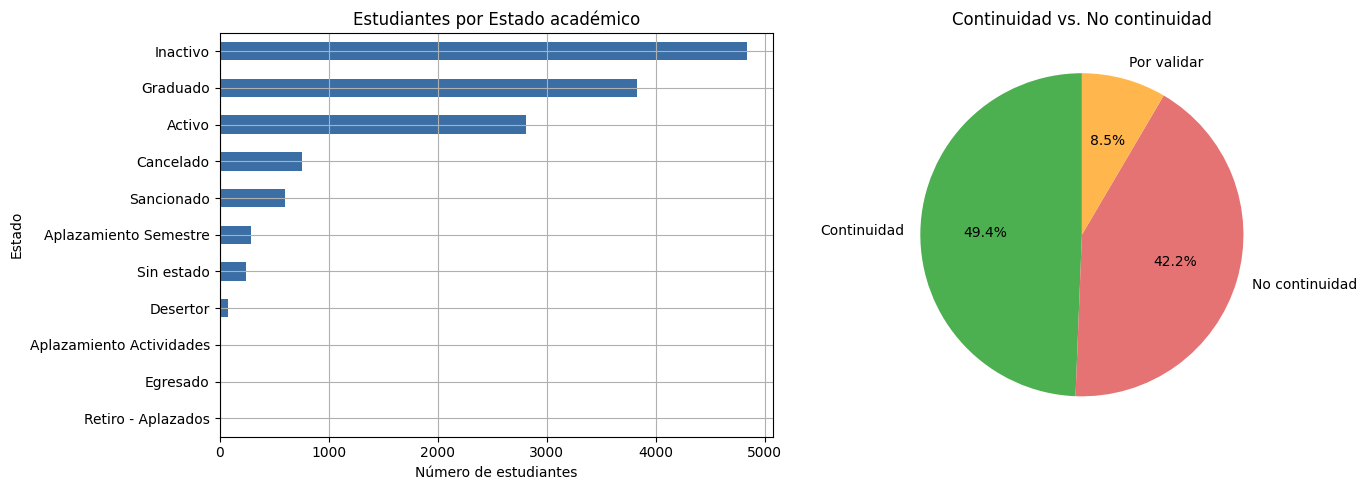

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Estado'].value_counts().plot(kind='barh', ax=axes[0], color='#3b6ea5')
axes[0].set_title('Estudiantes por Estado académico')
axes[0].set_xlabel('Número de estudiantes')
axes[0].invert_yaxis()

df['Categoria'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
    colors=['#4caf50', '#e57373', '#ffb74d'])
axes[1].set_title('Continuidad vs. No continuidad')
axes[1].set_ylabel('')

plt.tight_layout(); plt.show()

**Resultado:** los estados más frecuentes son *Inactivo* (35,9 %), *Graduado* (28,5 %) y *Activo* (20,9 %). Al agrupar en la variable objetivo, el **49,4 %** corresponde a continuidad, el **42,2 %** a no continuidad y un **8,5 %** queda por validar.

**Respuesta:** casi la mitad de los registros históricos refleja una situación de no continuidad (inactividad, cancelación o deserción). La inactividad es, por mucho, el estado individual más grande.

**Conclusión / hipótesis:** el volumen de "Inactivo" es tan alto que probablemente mezcla deserción real con inactividad administrativa (estudiantes que terminaron un ciclo y no se rematricularon). *Hipótesis:* depurar y validar con CEFIT qué significa "Inactivo" cambiará de forma importante la tasa real de deserción; sin esa validación, el 42,2 % es un techo, no la deserción efectiva.

---
## Pregunta 2 · ¿Cuál es el perfil sociodemográfico de los estudiantes?

In [10]:
print('GÉNERO:'); print(df['Género'].value_counts())
print('\nEDAD (estadísticos):'); print(df['Edad'].describe().round(1))
print('\nESTRATO:'); print(df['Estrato'].value_counts(dropna=False).sort_index())
print('\nZONA:'); print(df['Zona'].value_counts(dropna=False))

GÉNERO:
Género
Masculino     7141
Femenino      6319
Sin genero       1
Name: count, dtype: int64

EDAD (estadísticos):
count    13441.0
mean        28.4
std         11.2
min          1.0
25%         20.0
50%         26.0
75%         34.0
max         79.0
Name: Edad, dtype: float64

ESTRATO:
Estrato
0.0      46
1.0     392
2.0    5326
3.0    5591
4.0     673
5.0     138
6.0      27
NaN    1268
Name: count, dtype: int64

ZONA:
Zona
Urbana            10867
NaN                1301
Rural               831
Urbana - rural      436
Sin dato             26
Name: count, dtype: int64


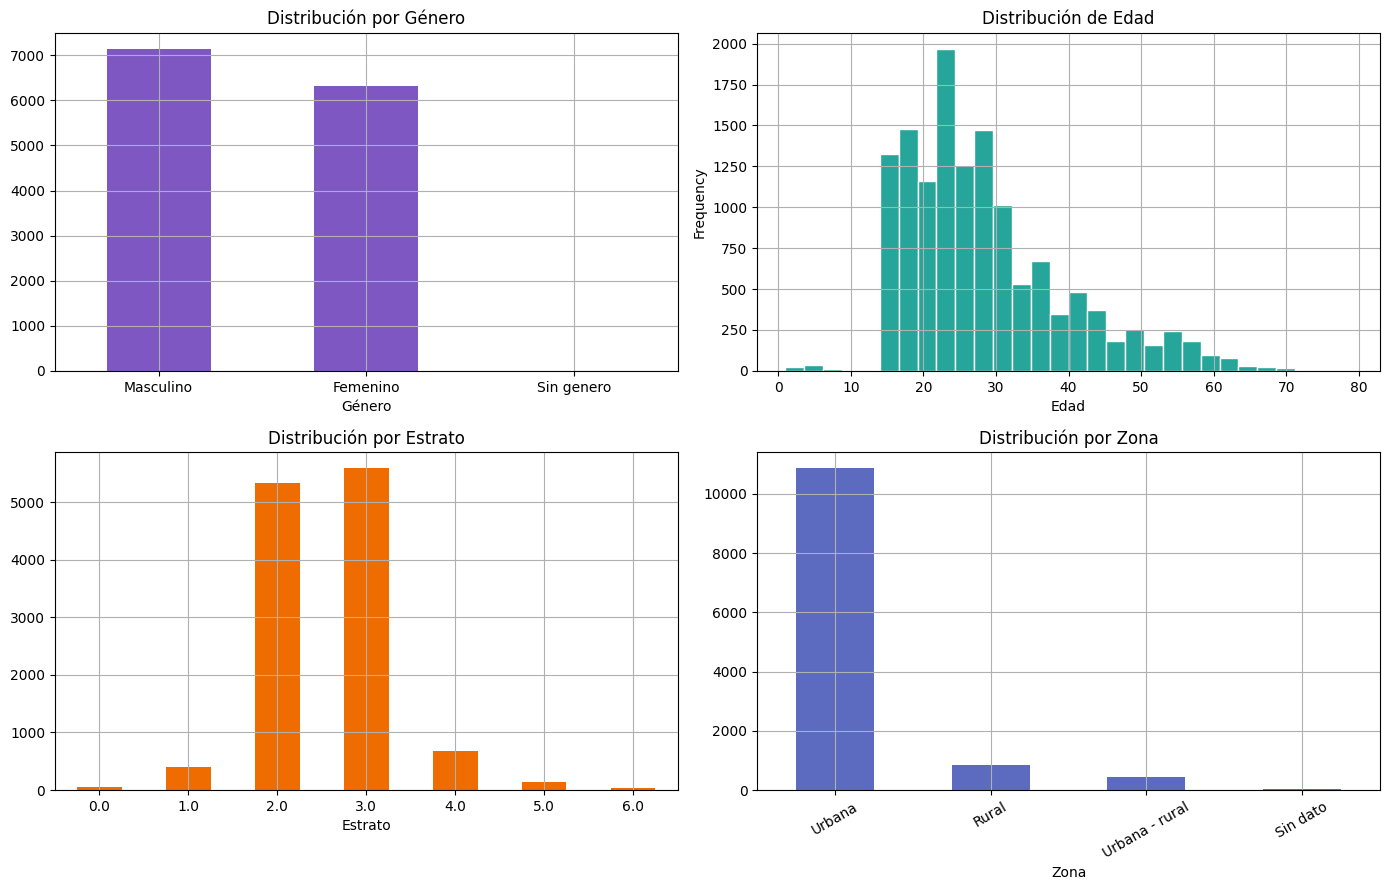

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df['Género'].value_counts().plot(kind='bar', ax=axes[0,0], color='#7e57c2')
axes[0,0].set_title('Distribución por Género'); axes[0,0].tick_params(axis='x', rotation=0)

df['Edad'].dropna().plot(kind='hist', bins=30, ax=axes[0,1], color='#26a69a', edgecolor='white')
axes[0,1].set_title('Distribución de Edad'); axes[0,1].set_xlabel('Edad')

df['Estrato'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='#ef6c00')
axes[1,0].set_title('Distribución por Estrato'); axes[1,0].tick_params(axis='x', rotation=0)

df['Zona'].value_counts().plot(kind='bar', ax=axes[1,1], color='#5c6bc0')
axes[1,1].set_title('Distribución por Zona'); axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

**Resultado:** población equilibrada por género (53 % masculino, 47 % femenino), edad mediana de **26 años** (la mayoría entre 20 y 34), concentración en **estratos 2 y 3** (más del 80 % de los que reportan estrato) y predominio de **zona urbana** (cerca del 90 %).

**Respuesta:** el estudiante típico de CEFIT es un adulto joven, urbano, de estrato medio-bajo.

**Conclusión / hipótesis:** el perfil socioeconómico (estratos 2–3) sugiere que factores económicos y laborales pueden pesar en la permanencia. *Hipótesis:* las estrategias de retención tendrán más impacto si contemplan apoyo socioeconómico y flexibilidad de horarios, dado el perfil de adulto joven que probablemente trabaja o busca empleo.

---
## Pregunta 3 · ¿Qué jornadas concentran la mayor tasa de no continuidad?

In [12]:
# Trabajamos solo con registros clasificables (continuidad / no continuidad)
clasif = df[df['Categoria'].isin(['Continuidad', 'No continuidad'])]

tasa_jornada = (clasif.groupby('Jornada')['Categoria']
                .apply(lambda s: (s == 'No continuidad').mean() * 100)
                .round(1).sort_values(ascending=False))
conteo_jornada = clasif['Jornada'].value_counts()
tabla3 = pd.DataFrame({'Estudiantes': conteo_jornada,
                       'Tasa no continuidad (%)': tasa_jornada}).dropna()
tabla3

,Estudiantes,Tasa no continuidad (%)
Jornada,,
DIURNA,3868,33.7
MEDIA TÉCNICA,2682,74.3
NOCHE,5644,40.0
SÁBADOS,1,0.0
TARDE,5,0.0


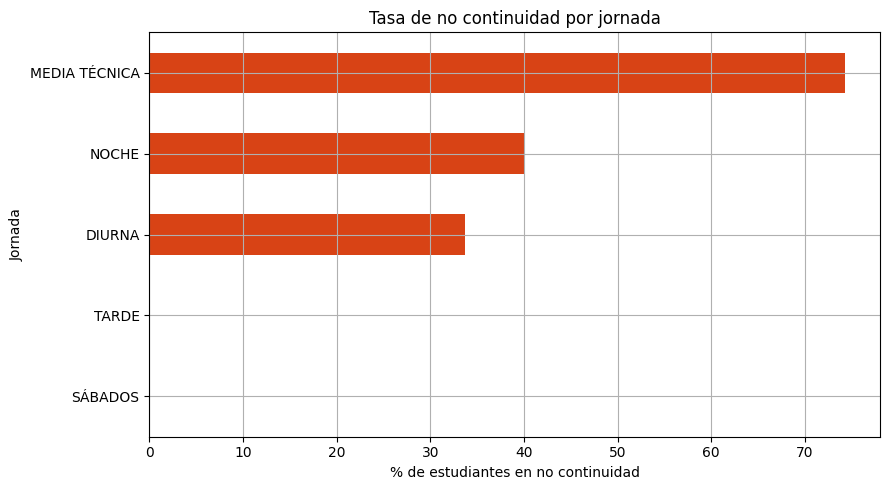

In [13]:
tabla3['Tasa no continuidad (%)'].sort_values().plot(
    kind='barh', color='#d84315')
plt.title('Tasa de no continuidad por jornada')
plt.xlabel('% de estudiantes en no continuidad')
plt.tight_layout(); plt.show()

**Resultado:** la jornada **Media Técnica** presenta la tasa de no continuidad más alta (~74 %), seguida de **Noche** (~40 %) y **Diurna** (~34 %).

**Respuesta:** las jornadas no son homogéneas; Media Técnica está muy por encima del resto.

**Conclusión / hipótesis:** la Media Técnica corresponde a estudiantes de colegio en orientación vocacional, donde "inactivo" suele significar fin del ciclo escolar más que deserción voluntaria. *Hipótesis:* parte de la alta tasa de Media Técnica es un artefacto de la definición de Estado, no abandono real; conviene analizarla por separado de las jornadas Noche y Diurna, donde la no continuidad sí refleja mejor el riesgo de deserción.

---
## Pregunta 4 · ¿Qué programas presentan mayor y menor riesgo de no continuidad?

In [14]:
prog = (clasif.groupby('Programa')
        .agg(Estudiantes=('Categoria', 'size'),
             Tasa_no_cont=('Categoria', lambda s: (s == 'No continuidad').mean() * 100)))
# Solo programas con suficiente volumen para ser comparables
prog = prog[prog['Estudiantes'] >= 100].round(1)

print('TOP 5 programas con MAYOR no continuidad:')
display(prog.sort_values('Tasa_no_cont', ascending=False).head(5))
print('TOP 5 programas con MENOR no continuidad (mejor permanencia):')
display(prog.sort_values('Tasa_no_cont').head(5))

TOP 5 programas con MAYOR no continuidad:


,Estudiantes,Tasa_no_cont
Programa,,
MEDIA TÉCNICA MECÁNICA MOTOS,118,89.0
MEDIA TÉCNICA - ORIENTACIÓN VOCACIONAL,1539,88.5
MEDIA TECNICA TECNICO LABORAL EN ENTRENAMIENTO DEPORTIVO,326,69.0
TÉCNICO LABORAL EN ELECTRÓNICA Y ELECTRICIDAD AUTOMOTRIZ,203,62.1
MEDIA TÉCNICA MERCADEO Y VENTAS,172,59.9


TOP 5 programas con MENOR no continuidad (mejor permanencia):


,Estudiantes,Tasa_no_cont
Programa,,
EXTENSIÓN MANIPULACIÓN DE ALIMENTOS,149,0.0
EXTENSIÓN - BIOSEGURIDAD,250,6.0
22T-TÉCNICO LABORAL EN MARKETING DIGITAL,222,16.2
12T-TÉCNICO LABORAL EN AUXILIAR DE RECURSO HUMANO,120,17.5
18T-TÉCNICO LABORAL EN GASTRONOMÍA,136,17.6


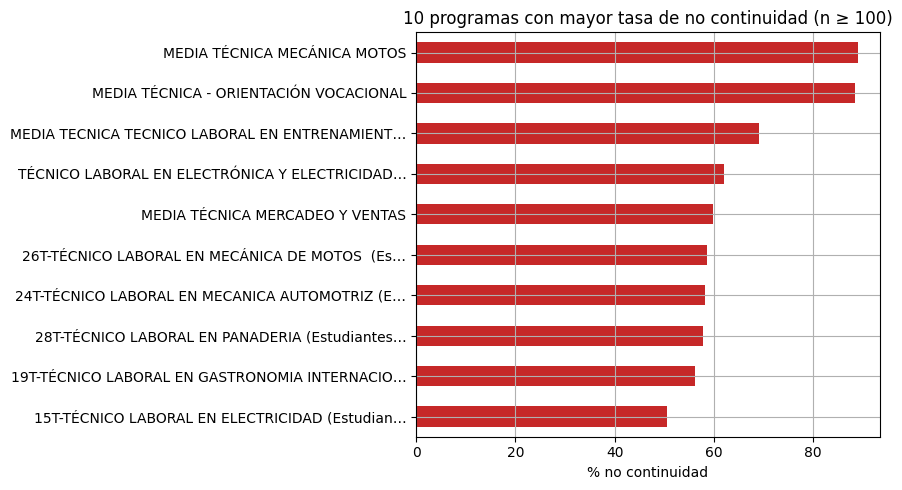

In [15]:
top = prog.sort_values('Tasa_no_cont', ascending=False).head(10)
# Acortamos los nombres largos para el gráfico
top.index = [n[:45] + '…' if len(n) > 45 else n for n in top.index]
top['Tasa_no_cont'].sort_values().plot(kind='barh', color='#c62828')
plt.title('10 programas con mayor tasa de no continuidad (n ≥ 100)')
plt.xlabel('% no continuidad')
plt.tight_layout(); plt.show()

**Resultado:** los programas con mayor no continuidad son de **Media Técnica** y técnicos antiguos (mecánica de motos, orientación vocacional, entrenamiento deportivo), por encima del 60 %. En el otro extremo, los cursos de **extensión** (manipulación de alimentos, bioseguridad) y técnicos como **Marketing Digital** y **Gastronomía** muestran las mejores tasas de permanencia.

**Respuesta:** el riesgo se concentra fuertemente en pocos programas; no es un fenómeno parejo en toda la oferta.

**Conclusión / hipótesis:** los cursos cortos de extensión retienen mejor por su duración y enfoque práctico, mientras que los programas largos y los antiguos acumulan más inactividad. *Hipótesis:* priorizar acompañamiento en los programas de la franja superior daría el mayor retorno; además, varios "técnicos antiguos" probablemente ya no admiten estudiantes, lo que infla artificialmente su inactividad histórica.

---
## Pregunta 5 · ¿Existe relación entre edad y género con la continuidad?

In [16]:
# Edad mediana por categoría
print('Edad mediana por categoría:')
print(clasif.groupby('Categoria')['Edad'].median())
print()
# Género vs categoría (proporción dentro de cada género)
tabla_gen = pd.crosstab(df['Género'], df['Categoria'], normalize='index') * 100
tabla_gen.round(1)

Edad mediana por categoría:
Categoria
Continuidad       27.0
No continuidad    24.0
Name: Edad, dtype: float64



Categoria,Continuidad,No continuidad,Por validar
Género,,,
Femenino,54.4,37.6,8.0
Masculino,44.9,46.2,8.9
Sin genero,0.0,100.0,0.0


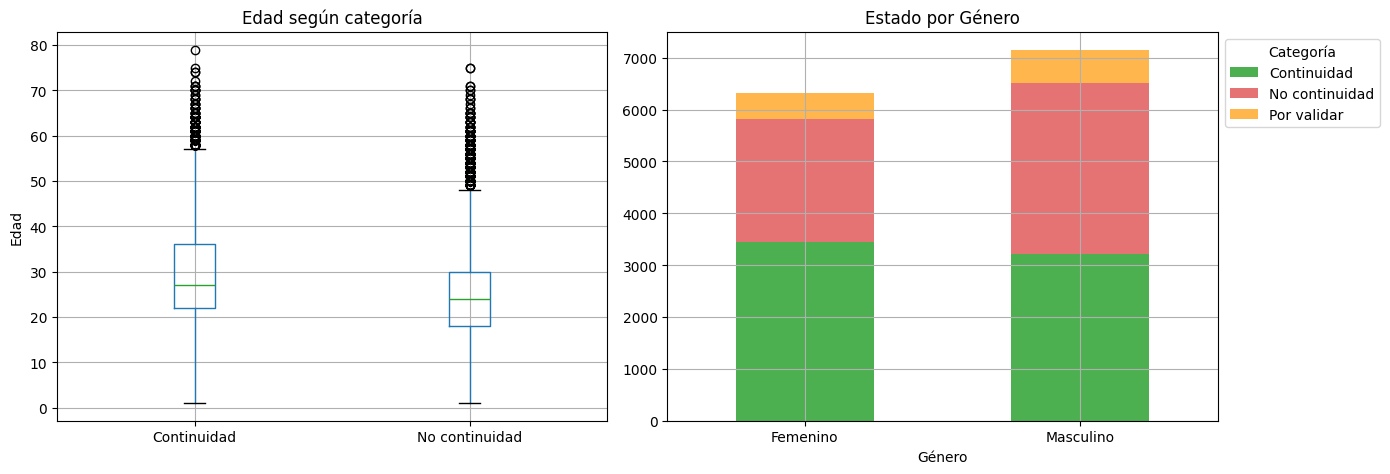

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clasif.boxplot(column='Edad', by='Categoria', ax=axes[0])
axes[0].set_title('Edad según categoría'); axes[0].set_xlabel(''); axes[0].set_ylabel('Edad')
plt.suptitle('')

cross = pd.crosstab(df['Género'], df['Categoria'])
cross = cross.loc[cross.sum(axis=1) > 5]  # quitamos categorías marginales
cross.plot(kind='bar', stacked=True, ax=axes[1],
           color=['#4caf50', '#e57373', '#ffb74d'])
axes[1].set_title('Estado por Género'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Categoría', bbox_to_anchor=(1, 1))

plt.tight_layout(); plt.show()

**Resultado:** la edad mediana de quienes están en no continuidad (24 años) es algo menor que la de continuidad (27 años). Por género, las mujeres muestran más continuidad (54 % vs. 45 % en hombres) y los hombres más no continuidad (46 % vs. 38 %).

**Respuesta:** sí hay relación, aunque moderada: ser más joven y hombre se asocia a algo más de no continuidad.

**Conclusión / hipótesis:** las diferencias existen pero no son enormes, lo que indica que edad y género solos no explican la deserción. *Hipótesis:* estas variables servirán como predictoras secundarias en el modelo, pero el programa y la jornada (Preguntas 3 y 4) tienen mayor poder discriminante; el modelo predictivo debería combinarlas en lugar de usarlas por separado.

---
## Pregunta 6 · ¿Cómo ha evolucionado la matrícula a lo largo de los períodos?

In [18]:
matricula_anio = df['Anio_Periodo'].value_counts().sort_index()
matricula_anio = matricula_anio[matricula_anio.index >= 2014]  # rango confiable
print(matricula_anio)

Anio_Periodo
2014.0      79
2015.0    1036
2016.0    1358
2017.0    1636
2018.0    1506
2019.0    1378
2020.0    2369
2021.0    2065
2022.0     817
2026.0     851
Name: count, dtype: int64


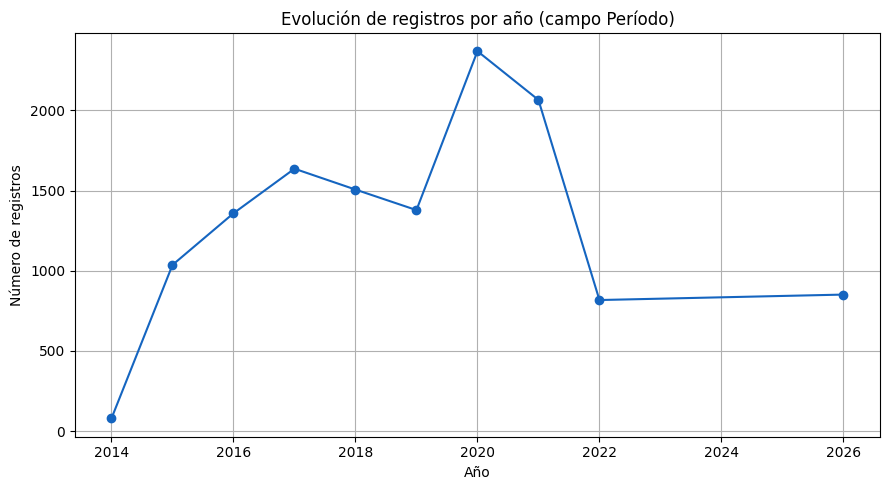

In [19]:
matricula_anio.plot(kind='line', marker='o', color='#1565c0')
plt.title('Evolución de registros por año (campo Período)')
plt.xlabel('Año'); plt.ylabel('Número de registros')
plt.tight_layout(); plt.show()

**Resultado:** los registros se concentran entre 2014 y 2026, con un volumen alto y relativamente sostenido entre 2017 y 2022. El último año puede aparecer incompleto porque el período aún está en curso.

**Respuesta:** CEFIT mantiene una matrícula histórica estable, con suficiente masa de datos por año para análisis por cohortes.

**Conclusión / hipótesis:** la continuidad histórica de los datos permite construir series y comparar cohortes. *Hipótesis:* analizar la no continuidad por año de ingreso (cohorte) revelará si el riesgo ha aumentado o disminuido con el tiempo, información clave para fijar metas de reducción de deserción por período.

---
## Pregunta 7 · ¿Qué problemas de calidad de datos y anomalías existen?

In [20]:
# Recargamos el original para mostrar el estado SIN limpiar
orig = pd.read_csv(RUTA)
orig.columns = orig.columns.str.strip()

print('1) Edades imposibles en el archivo original:')
print('   - Edad mínima cruda:', orig['Edad'].min(), '(valor imposible)')
print('   - Registros con edad <= 0:', int((orig['Edad'] <= 0).sum()))
print()
print('2) Valores faltantes (top):')
print(orig.isnull().sum().sort_values(ascending=False).head(8))
print()
print('3) Categorías no estandarizadas que requieren homologación:')
print('   - "Sin respuesta" en EPS:', int((orig['EPS'] == 'Sin respuesta').sum()))
print('   - Programas distintos:', orig['Programa'].nunique(), '(muchos por antigüedad/duplicados)')

1) Edades imposibles en el archivo original:
   - Edad mínima cruda: -973.0 (valor imposible)
   - Registros con edad <= 0: 19

2) Valores faltantes (top):
Ocupación             1918
Zona                  1301
Estrato               1268
Fecha de Matrícula    1217
Período                366
Nivel                  366
Jornada                123
Programa               123
dtype: int64

3) Categorías no estandarizadas que requieren homologación:
   - "Sin respuesta" en EPS: 0
   - Programas distintos: 78 (muchos por antigüedad/duplicados)


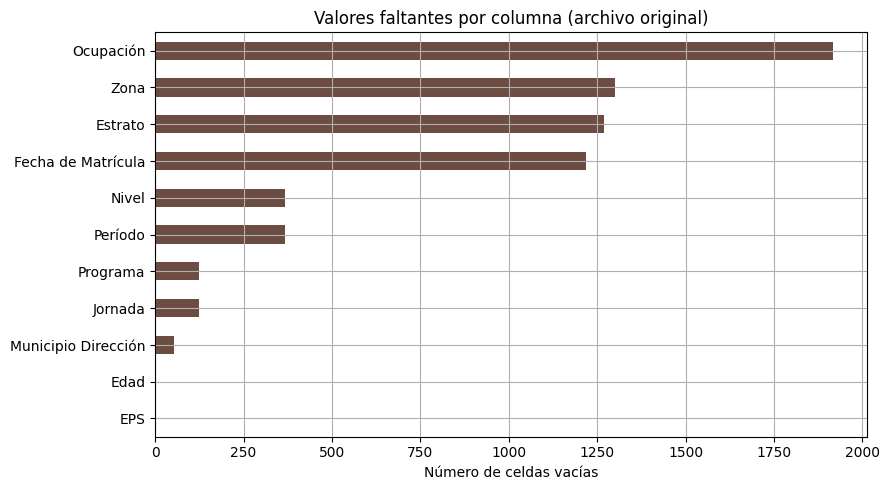

In [21]:
faltantes = orig.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values()
faltantes.plot(kind='barh', color='#6d4c41')
plt.title('Valores faltantes por columna (archivo original)')
plt.xlabel('Número de celdas vacías')
plt.tight_layout(); plt.show()

**Resultado:** se confirman las anomalías de la propuesta: al menos una **edad negativa** (valor imposible cercano a -973), y faltantes relevantes en *Ocupación* (1.918), *Zona* (1.301), *Estrato* (1.268), *Fecha de Matrícula* (1.217) y *Período/Nivel* (366). Existen **78 programas** distintos, varios marcados como "antiguos", y categorías como "Sin respuesta"/"SIN DATO".

**Respuesta:** el dataset es utilizable, pero exige depuración antes de modelar.

**Conclusión / hipótesis:** la calidad de los datos es hoy el principal limitante del producto. *Hipótesis:* estandarizar programas y validar el significado de cada Estado con CEFIT reducirá el ruido más que cualquier ajuste del modelo; la imputación de nulos en Estrato/Ocupación debe hacerse con cuidado porque esas variables son candidatas a predictoras del riesgo.

---
## Conclusiones generales e hipótesis

1. **La no continuidad es alta pero ambigua.** El 42 % de registros cae en no continuidad, pero está dominado por "Inactivo", que mezcla deserción real con cierres administrativos. *Validar la definición de Estado con CEFIT es el paso previo indispensable.*

2. **El riesgo no es uniforme: se concentra por jornada y programa.** Media Técnica y los programas técnicos antiguos concentran el mayor riesgo; los cursos de extensión retienen mejor. El programa y la jornada son las variables más informativas para un modelo predictivo.

3. **El perfil socioeconómico importa.** Población joven, urbana y de estratos 2–3 sugiere que el apoyo socioeconómico y la flexibilidad horaria son palancas de retención.

4. **Edad y género influyen de forma moderada.** Útiles como predictoras secundarias, pero insuficientes por sí solas.

5. **La calidad de datos es el cuello de botella.** Edades imposibles, nulos y 78 programas sin estandarizar deben corregirse antes de cualquier modelo.

**Recomendaciones para la siguiente fase (según la propuesta):**
- Validar con CEFIT la variable objetivo *Riesgo de no continuidad*.
- Construir un modelo de clasificación (regresión logística / Random Forest) usando programa, jornada, edad, género, estrato y ocupación.
- Diseñar un tablero por programa, jornada y período, con una lista priorizada de estudiantes para seguimiento.

> *Este cuaderno cubre la analítica descriptiva. La clasificación supervisada y la segmentación quedan como las siguientes etapas del producto de datos.*